# **Project Name**    - Time series Forecasting-FBI Crime investigation



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team
##### **Team Member 1 -**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Dataset Loading

In [3]:
import os
os.listdir('../data')

['Test.csv', 'Train.xlsx']

In [4]:
train_df = pd.read_excel('../data/Train.xlsx')
test_df = pd.read_csv('../data/Test.csv')                        

### Dataset First View

In [5]:
# Dataset First Look
train_df.head()

,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
0,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,15.0,1999,5,12,1999-05-12
1,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,15.0,20.0,1999,5,7,1999-05-07
2,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,40.0,1999,4,23,1999-04-23
3,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,11.0,15.0,1999,4,20,1999-04-20
4,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,17.0,45.0,1999,4,12,1999-04-12


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
train_df.shape

(474565, 13)

### Dataset Information

In [7]:
# Dataset Info
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 474565 entries, 0 to 474564
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TYPE           474565 non-null  str           
 1   HUNDRED_BLOCK  474552 non-null  str           
 2   NEIGHBOURHOOD  423074 non-null  str           
 3   X              474565 non-null  float64       
 4   Y              474565 non-null  float64       
 5   Latitude       474565 non-null  float64       
 6   Longitude      474565 non-null  float64       
 7   HOUR           425200 non-null  float64       
 8   MINUTE         425200 non-null  float64       
 9   YEAR           474565 non-null  int64         
 10  MONTH          474565 non-null  int64         
 11  DAY            474565 non-null  int64         
 12  Date           474565 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(6), int64(3), str(3)
memory usage: 47.1 MB


#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
train_df.duplicated().sum()

np.int64(44618)

In [9]:
train_df[train_df.duplicated()]

,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
154,Offence Against a Person,OFFSET TO PROTECT PRIVACY,NaN,0.0,0.0,0.0,0.0,NaN,NaN,1999,8,13,1999-08-13
228,Offence Against a Person,OFFSET TO PROTECT PRIVACY,NaN,0.0,0.0,0.0,0.0,NaN,NaN,1999,8,13,1999-08-13
320,Offence Against a Person,OFFSET TO PROTECT PRIVACY,NaN,0.0,0.0,0.0,0.0,NaN,NaN,1999,1,18,1999-01-18
321,Offence Against a Person,OFFSET TO PROTECT PRIVACY,NaN,0.0,0.0,0.0,0.0,NaN,NaN,1999,2,12,1999-02-12
413,Offence Against a Person,OFFSET TO PROTECT PRIVACY,NaN,0.0,0.0,0.0,0.0,NaN,NaN,1999,11,17,1999-11-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
466300,Offence Against a Person,OFFSET TO PROTECT PRIVACY,NaN,0.0,0.0,0.0,0.0,NaN,NaN,2011,3,13,2011-03-13
466308,Offence Against a Person,OFFSET TO PROTECT PRIVACY,NaN,0.0,0.0,0.0,0.0,NaN,NaN,2011,9,14,2011-09-14
466309,Offence Against a Person,OFFSET TO PROTECT PRIVACY,NaN,0.0,0.0,0.0,0.0,NaN,NaN,2011,8,17,2011-08-17
466317,Offence Against a Person,OFFSET TO PROTECT PRIVACY,NaN,0.0,0.0,0.0,0.0,NaN,NaN,2011,4,21,2011-04-21


In [10]:
duplicate_rows = train_df[train_df.duplicated()]

duplicate_rows.nunique()

TYPE                1
HUNDRED_BLOCK       1
NEIGHBOURHOOD       0
X                   1
Y                   1
Latitude            1
Longitude           1
HOUR                0
MINUTE              0
YEAR               13
MONTH              12
DAY                31
Date             4743
dtype: int64

#### Missing Values/Null Values

In [11]:
# Missing Values/Null Values Count
train_df.isnull().sum()

TYPE                 0
HUNDRED_BLOCK       13
NEIGHBOURHOOD    51491
X                    0
Y                    0
Latitude             0
Longitude            0
HOUR             49365
MINUTE           49365
YEAR                 0
MONTH                0
DAY                  0
Date                 0
dtype: int64

In [12]:
missing_values = train_df.isnull().sum()

missing_percentage = (
    train_df.isnull().sum() / len(train_df)
) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_df.sort_values(
    by='Percentage',
    ascending=False
)

,Missing Values,Percentage
NEIGHBOURHOOD,51491,10.850147
HOUR,49365,10.402158
MINUTE,49365,10.402158
HUNDRED_BLOCK,13,0.002739
TYPE,0,0.000000
Y,0,0.000000
X,0,0.000000
Longitude,0,0.000000
Latitude,0,0.000000
YEAR,0,0.000000


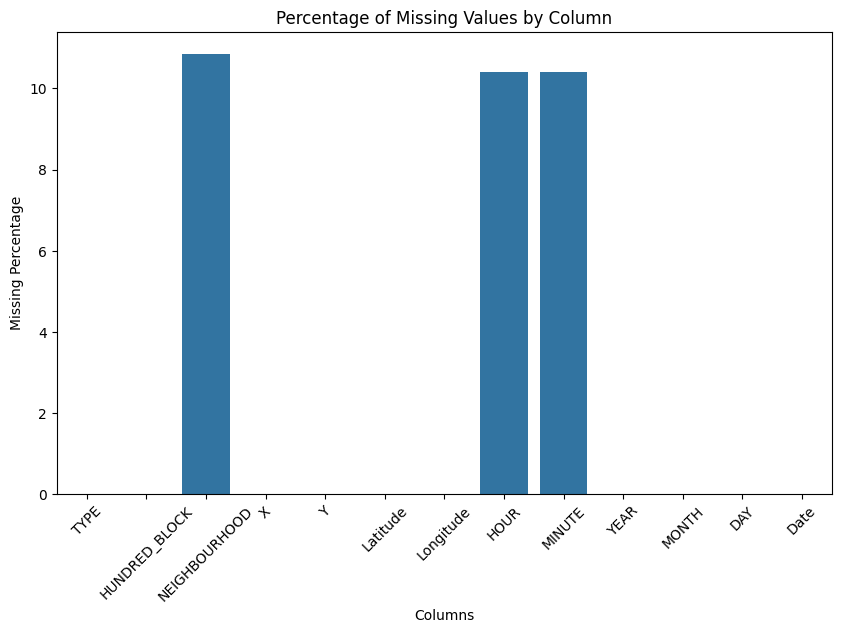

In [13]:
# Visualizing the missing values
plt.figure(figsize=(10,6))

sns.barplot(
    x=missing_df.index,
    y=missing_df['Percentage']
)

plt.title('Percentage of Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Missing Percentage')

plt.xticks(rotation=45)

plt.show()


In [14]:
# Count Zero Coordinates
zero_lat = (train_df['Latitude'] == 0).sum()
zero_long = (train_df['Longitude'] == 0).sum()

print("Zero Latitude:", zero_lat)
print("Zero Longitude:", zero_long)

Zero Latitude: 49365
Zero Longitude: 49365


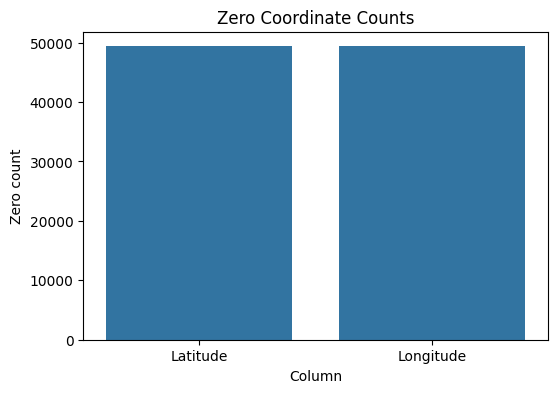

In [15]:
# Visualize Zero coordinates
zero_df = pd.DataFrame ({'Column': ['Latitude', 'Longitude'], 'Zero count': [zero_lat,zero_long]})

plt.figure(figsize =(6,4))
sns.barplot(x ='Column', y ='Zero count', data = zero_df)

plt.title('Zero Coordinate Counts')
plt.show()

In [16]:
missing_df.style.background_gradient(cmap='Reds')

,Missing Values,Percentage
TYPE,0,0.000000
HUNDRED_BLOCK,13,0.002739
NEIGHBOURHOOD,51491,10.850147
X,0,0.000000
Y,0,0.000000
Latitude,0,0.000000
Longitude,0,0.000000
HOUR,49365,10.402158
MINUTE,49365,10.402158
YEAR,0,0.000000


### What did you know about your dataset?

##### The Dataset contains detailed crime incident records with temporal, spatial, and categorical information related to crime occurrences. Each row indicates an individual crime incident reported on a specific date, time, and location.
1. Using df.head(), the initial inspection revealed that the dataset includes:
    1. Crime categories(TYPE)
    2. Crime Location(HUNDRED_BLOCK, NEIGHBOURHOOD)
    3. Spatial information(X, Y, Latitude, Longitude)
    4. Temporal attributes(Hour, Minute, YEAR, MONTH, DAY, Date)
       
2. The shape function revealed that the dataset contains a large number of records and features (474565 records, 13 features), making it suitable for time-series and predictive analysis.

3. The info() output showed,
    - A combination of numerical, categorical and temporal variables
    - missing values in some columns
    - appropriate data types for coordinates and temporal features

##### The dataset appears sufficiently rich for performing 
    - Exploratory Data Analysis
    - Temporal Trend Analysis
    - Spatial Analysis
    - Machine-learning-based analysis


## **Duplicate Record Analysis**
##### Duplicate analysis reveals several rows with highly similar values, particularly in records associated with privacy-protected crime incidents. However, a detailed inspection revealed differences in temporal attributes, such as date, month, and year, indicating that these rows represent distinct crime events rather than accidental duplicate entries.
##### Many of these records contained:
    - "OFFSET TO PROTECT PRIVACY" in their location-related column
    - missing neighbourhood information
    - zero-valued coordinates
##### These patterns suggest intentional masking of sensitive information rather than data duplication. Therefore, no duplicate data will be removed to preserve valid crime incident records.


## Missing Value Analysis
##### The dataset contains moderate missingness in both temporal and spatial attributes.

##### Key Observations:
    - NEIGHBOURHOOD contains 10.85 percent of missing values.
    - HOUR and MINUTE contain 10.4 percent missing values each.
    - HUNDRED_BLOCK contains very few missing values. 
The identical percentage of missing values in HOUR and MINUTE indicates the absence of the time component from some records.

##### Additionally, some records contain zero-valued coordinates (Latitude, Longitude, X, Y) for some records, likely representing masked or unavailable spatial information for privacy-sensitive reports.

##### These missing values reflect common real-world challenges in crime datasets, including
    - incomplete recording,
    - privacy protection mechanisms,
    - inconsistent data collection practices.
    

## ***2. Understanding Your Variables***

In [17]:
# Dataset Columns
train_df.columns

Index(['TYPE', 'HUNDRED_BLOCK', 'NEIGHBOURHOOD', 'X', 'Y', 'Latitude',
       'Longitude', 'HOUR', 'MINUTE', 'YEAR', 'MONTH', 'DAY', 'Date'],
      dtype='str')

In [18]:
# Dataset Describe
train_df.describe()

,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
count,474565.000000,4.745650e+05,474565.000000,474565.000000,425200.000000,425200.000000,474565.000000,474565.000000,474565.000000,474565
mean,441028.018220,4.889023e+06,44.138029,-110.301025,13.721263,16.736047,2004.363632,6.555700,15.439253,2004-11-11 23:51:07.470209
min,0.000000,0.000000e+00,0.000000,-124.549757,0.000000,0.000000,1999.000000,1.000000,1.000000,1999-01-01 00:00:00
25%,489916.530000,5.453572e+06,49.234871,-123.127383,9.000000,0.000000,2001.000000,4.000000,8.000000,2001-06-06 00:00:00
50%,491477.850000,5.456820e+06,49.264051,-123.107058,15.000000,10.000000,2004.000000,7.000000,15.000000,2004-05-18 00:00:00
75%,493610.190000,5.458622e+06,49.280300,-123.065646,19.000000,30.000000,2008.000000,9.000000,23.000000,2008-03-27 00:00:00
max,511303.000000,5.512579e+06,49.755314,0.000000,23.000000,59.000000,2011.000000,12.000000,31.000000,2011-12-31 00:00:00
std,150295.319332,1.665850e+06,15.039271,37.583147,6.785751,18.354675,3.850689,3.408676,8.759352,NaN


### Variables Description

#### **Variable**   |  **Description**
--------------------
    TYPE            |  Category or type of crime incident
    HUNDRED_BLOCK   |  Approximate Street block location of the incident
    NEIGHBOURHOOD   |  Neighbourhood or locality where the incident occured
    X, Y            |  Spatial coordinate system values 
    Latitude        |  Geographic latitude coordinate
    Longitude       |  Geographic longitude coordinate
    HOUR, MINUTE    |  Hour and Minute during which the crime occured
    YEAR,MONTH,DAY  |  Year, month, and day of the crime 
    DATE            |  Exact date of the crime


#### Understanding Numerical variables using describe()
**Statistical summary analysis**
##### The describe() function was used to generate summary statistics for numerical variables in the dataset.
##### This provided insights into:
     - central tendency
     - variability
     - minimum and maximum values
     - possible outliers
     - feature distributions.
##### Key observations from the statistical analysis include:
    - Temporal variables such as YEAR, MONTH, DAY fall within the expected range, confirming data consistency.
    - The HOUR feature spans across 24-hour cycle, indicating that crime incidents occured throughout the day.
    - Geographic features(Latitude, longitude, X, Y) contain zero values, suggesting the presence of masked or unavailable spatial information for privacy-sensitive incidents.
    - Differences between minimum, median, and maximum values indicate variability in crime occurrence patterns across time and location.
    - The presence of wide-ranging coordinate values suggests strong spatial diversity in crime distribution.
    

### Check Unique Values for each variable.

In [19]:
# Check Unique Values for each variable.
train_df.nunique()

TYPE                 9
HUNDRED_BLOCK    20566
NEIGHBOURHOOD       24
X                84225
Y                82768
Latitude         89488
Longitude        87190
HOUR                24
MINUTE              60
YEAR                13
MONTH               12
DAY                 31
Date              4748
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [20]:
# Write your code to make your dataset analysis ready.
# Handling Missing Categorical values
# the missing values in NEIGHBOURHOOD are filled with 'Unknown'
train_df['NEIGHBOURHOOD'] = train_df['NEIGHBOURHOOD'].fillna('Unknown')

In [21]:
# Fill missing values in HUNDRED_BLOCK with 'Unknown'
train_df['HUNDRED_BLOCK'] = train_df['HUNDRED_BLOCK'].fillna('Unknown')

In [22]:
# Median imputation for missing values in HOUR and MINUTE
train_df['HOUR'] = train_df['HOUR'].fillna(train_df['HOUR'].median())
train_df['MINUTE'] = train_df['MINUTE'].fillna(train_df['MINUTE'].median())

In [23]:
# Finally checking after handling missing values
train_df.isnull().sum()

TYPE             0
HUNDRED_BLOCK    0
NEIGHBOURHOOD    0
X                0
Y                0
Latitude         0
Longitude        0
HOUR             0
MINUTE           0
YEAR             0
MONTH            0
DAY              0
Date             0
dtype: int64

In [24]:
# Conversion to datetime 

### What all manipulations have you done and insights you found?

##### **1. Handling Missing values**
Missing values in categorical variables 'NEIGHBOURHOOD' and 'HUNDRED_BLOCK' were replaced with 'Unknown' to preserve important records while maintaining category consistency.
Temporal variables 'HOUR' and 'MINUTE' were imputed with the median value to minimize distortion caused by skewed temporal distributions.

##### **2. Datetime datatype Handling**
The Date variable in the dataset is already in datetime64(us) format, allowing direct extraction of datetime features such as month, date, year. This ensured compatibility with time-series analysis.

##### **3. Duplicate value inspection**
Duplicate record analysis revealed that many incidents with similar crime TYPE are recorded on different dates. This identifies the crime records as different individual records. Therefore, the records were not removed from the dataset to avoid losing important records.

##### **4. Handling Invalid spatial values**
Zero-valued coordinates in the dataset are identified as missing spatial information. They are masked or unavailable spatial information associated with privacy-protected records. 

##### **5. Data Consistency Validation**
The date, year, month, and hour temporal information were checked carefully to ensure values remain within expected ranges.



## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### **Temporal Analysis**

#### Chart - 1 Monthly Crime Trend

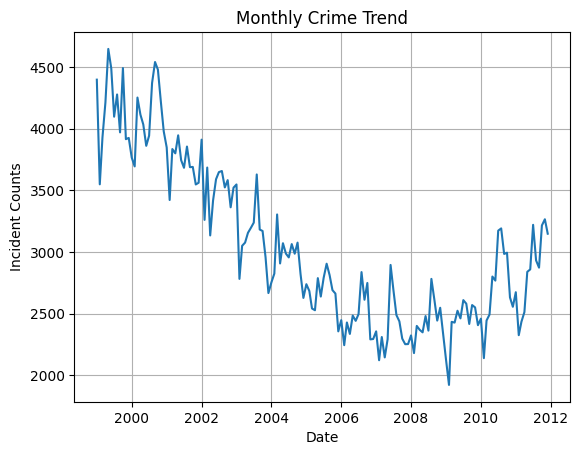

In [26]:
# Chart - 1 visualization code
# Creating a dataset grouped by Month  
monthly_df = train_df.groupby(['YEAR', 'MONTH']).size().reset_index(name = 'Incident_Counts')

monthly_df['Date'] = pd.to_datetime(monthly_df['YEAR'].astype(str) + '-' + monthly_df['MONTH'].astype(str) + '-01')

plt.plot(monthly_df['Date'], monthly_df['Incident_Counts'])
plt.title('Monthly Crime Trend')
plt.xlabel('Date')
plt.ylabel('Incident Counts')
plt.grid(True)

plt.savefig('../outputs/monthly_crime_trend.png')

plt.show()
                                    

##### 1. Why did you pick the specific chart?

A line plot was used to analyze long-term temporal trends and fluctuations in crime incidents over time.

##### 2. What is/are the insight(s) found from the chart?

**1. Overall Downward Trend (1998-2009)**
- The chart shows a noticeable decline in monthly crime incidents from approximately 1998 to 2009.
- Crime counts decreased from nearly 4500+ incidents per month to nearly 2200-2500 counts per month. This suggests a substantial long-term reduction in crime incidents during this period.
Possible reasons may include
- improved policies
- technological surveillance advancements
- increased safety initiatives
- demographic and economic changes
  
**2. Seasonal and Periodic Trend**
Although the graph shows a long-term decline, the numbers repeatedly show short-term rise and fall throughout the period.
This indicates-
- seasonality
- cyclical crime behaviour
- recurring temporal patterns,
Such fluctuations are extremely important for forecasting models because they suggest that crime incidents are not random and may depend on
- month
- season
- social activity periods
- holidays
- weather conditions.

**3. Unusual Peaks and Drops**
Several abrupt peaks and drops are visible inside the long-term trend.
- Peaks between 2000 and 2001
- localized spikes after 2010
These abrupt increases and declines in crime suggest
- specific crime surges
- policy changes
- economic events
- exceptional incidents.
Such irregularities highlight the importance of robust forecasting models capable of handling volatility.

**4. Crime Increase after 2010**
After 2010, crime incidents again increased, as indicated by the data in the graph.
This suggests,
- changing social conditions
- decreased number of reporting
- evolving crime dynamics
- possible urban growth effects.
  
This indicates crime trends are dynamic rather than steadily decreasing over time.

  

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

In [ ]:
# Chart - 2 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

In [ ]:
# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

In [ ]:
# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

In [ ]:
# Chart - 5 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

In [ ]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [ ]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [ ]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [ ]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [ ]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [ ]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [ ]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [ ]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [ ]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data

### 6. Data Scaling

In [ ]:
# Scaling your data

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***